In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import datetime
import yaml
import json

import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision.transforms import v2
from torchvision.io import decode_image
from torchvision.models import resnet50

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import src.analysis

#####

with open("config/common.yaml", "r") as common_params:
    common = yaml.safe_load(common_params)
    # unpack params
    conditions = common["conditions"]
    class_cols = common["class_cols"]
    n_classes = common["n_classes"]
    n_class_values = common["n_class_values"]

pred_cols = [col + "_pred" for col in class_cols]
confidence_cols = [col + "_confidence" for col in class_cols]

# Analyzing Model Results

This notebook is split into two sections:

* The first section shows the results of a single model
* The second section shows the results for multiple models (The results file paths *must* exist)

### Analyzing Results for a Single Model

In [2]:
analyze_single_model = False

if analyze_single_model:
    # Edit the result filepath here
    results_file_paths = dict(
        model = "results/ResNet50_BASE224_test_withPredictionsAndConfidences.csv"
    )
    # Set include_certain_vs_uncertain if that analysis should be included
    include_certain_vs_uncertain0 = True
    
    #####
    results = scripts.analysis.get_all_metrics(results_file_paths, include_certain_vs_uncertain=include_certain_vs_uncertain0)

    # Convert dictionary to data frame
    results_df = scripts.analysis.results_to_df(dict(model=results))

    # Save results
    with open("results/model_metrics/single_model_metrics.json", "w") as fh:
        json.dump(results, fh)
    results_df.to_csv("results/model_metrics/single_model_metrics.csv", index=False)

### Analyzing Results for Multiple Models

To view results for multiple models, make sure the corresponding file path below is activated. Comment out any model file paths that should not be included in the analysis.

In [3]:
### Get metrics for test results
test_results_file_paths = dict(
    resnet_base224 = "results/ResNet50_BASE224_test_withPredictionsAndConfidences.csv",
    resnet_base224_enhanced = "results/ResNet50_BASE224_ENHANCED_test_withPredictionsAndConfidences.csv",
    densenet_base224 = "results/DenseNet121_BASE224_test_withPredictionsAndConfidences.csv",
    densenet_base224_enhanced = "results/DenseNet121_BASE224_ENHANCED_test_withPredictionsAndConfidences.csv",
    #
    resnet_base384 = "results/ResNet50_BASE384_test_withPredictionsAndConfidences.csv",
    resnet_base384_enhanced = "results/ResNet50_BASE384_ENHANCED_test_withPredictionsAndConfidences.csv",
    densenet_base384 = "results/DenseNet121_BASE384_test_withPredictionsAndConfidences.csv",
    densenet_base384_enhanced = "results/DenseNet121_BASE384_ENHANCED_test_withPredictionsAndConfidences.csv",
    #
    resnet_base512 = "results/ResNet50_BASE512_test_withPredictionsAndConfidences.csv",
    resnet_base512_enhanced = "results/ResNet50_BASE512_ENHANCED_test_withPredictionsAndConfidences.csv",
    densenet_base512 = "results/DenseNet121_BASE512_test_withPredictionsAndConfidences.csv",
    densenet_base512_enhanced = "results/DenseNet121_BASE512_ENHANCED_test_withPredictionsAndConfidences.csv"
)

test_results = src.analysis.get_all_metrics(test_results_file_paths, include_certain_vs_uncertain=True)
    

These models will be analyzed:
    resnet_base224
    resnet_base224_enhanced
    densenet_base224
    densenet_base224_enhanced
    resnet_base384
    resnet_base384_enhanced
    densenet_base384
    densenet_base384_enhanced
    resnet_base512
    resnet_base512_enhanced
    densenet_base512
    densenet_base512_enhanced


In [4]:
### Get metrics for radiologist-labeled validation results
valid_rad_results_file_paths = dict(
    resnet_base224 = "results/ResNet50_BASE224_valid_rad_withPredictionsAndConfidences.csv",
    resnet_base224_enhanced = "results/ResNet50_BASE224_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base224 = "results/DenseNet121_BASE224_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base224_enhanced = "results/DenseNet121_BASE224_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base384 = "results/ResNet50_BASE384_valid_rad_withPredictionsAndConfidences.csv",
    resnet_base384_enhanced = "results/ResNet50_BASE384_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base384 = "results/DenseNet121_BASE384_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base384_enhanced = "results/DenseNet121_BASE384_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base512 = "results/ResNet50_BASE512_valid_rad_withPredictionsAndConfidences.csv",
    resnet_base512_enhanced = "results/ResNet50_BASE512_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base512 = "results/DenseNet121_BASE512_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base512_enhanced = "results/DenseNet121_BASE512_ENHANCED_valid_rad_withPredictionsAndConfidences.csv"
)

valid_rad_results = src.analysis.get_all_metrics(valid_rad_results_file_paths, include_certain_vs_uncertain=False)
    

These models will be analyzed:
    resnet_base224
    resnet_base224_enhanced
    densenet_base224
    densenet_base224_enhanced
    resnet_base384
    resnet_base384_enhanced
    densenet_base384
    densenet_base384_enhanced
    resnet_base512
    resnet_base512_enhanced
    densenet_base512
    densenet_base512_enhanced


In [5]:
### Get metrics for radiologist-labeled validation results
test_rad_results_file_paths = dict(
    resnet_base224 = "results/ResNet50_BASE224_test_rad_withPredictionsAndConfidences.csv",
    resnet_base224_enhanced = "results/ResNet50_BASE224_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    densenet_base224 = "results/DenseNet121_BASE224_test_rad_withPredictionsAndConfidences.csv",
    densenet_base224_enhanced = "results/DenseNet121_BASE224_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base384 = "results/ResNet50_BASE384_test_rad_withPredictionsAndConfidences.csv",
    resnet_base384_enhanced = "results/ResNet50_BASE384_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    densenet_base384 = "results/DenseNet121_BASE384_test_withPredictionsAndConfidences.csv",
    densenet_base384_enhanced = "results/DenseNet121_BASE384_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base512 = "results/ResNet50_BASE512_test_rad_withPredictionsAndConfidences.csv",
    resnet_base512_enhanced = "results/ResNet50_BASE512_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    densenet_base512 = "results/DenseNet121_BASE512_test_rad_withPredictionsAndConfidences.csv",
    densenet_base512_enhanced = "results/DenseNet121_BASE512_ENHANCED_test_rad_withPredictionsAndConfidences.csv"
)

test_rad_results = src.analysis.get_all_metrics(test_rad_results_file_paths, include_certain_vs_uncertain=False)
    

These models will be analyzed:
    resnet_base224
    resnet_base224_enhanced
    densenet_base224
    densenet_base224_enhanced
    resnet_base384
    resnet_base384_enhanced
    densenet_base384
    densenet_base384_enhanced
    resnet_base512
    resnet_base512_enhanced
    densenet_base512
    densenet_base512_enhanced


In [6]:
results = dict(
    test_results=test_results,
    valid_rad_results=valid_rad_results,
    test_rad_results=test_rad_results
)

In [7]:
### Navigating the dictionary
for results_df_name,results_df in results.items():
    """
    At this level, choose the data frame being analyzed 
    (
    test_results, test_rad_results, valid_rad_results
    )
    """
    for model_name,model in results[results_df_name].items():
        """
        At this level choose the specific model configuration being analyzed
        (
        resnet_base224, resnet_base384, resnet_base512,
        densenet_base224, densenet_base384, densenet_base512,
        resnet_base224_enhanced, resnet_base384_enhanced, resnet_base512_enhanced,
        densenet_base224_enhanced, densenet_base384_enhanced, densenet_base512_enhanced
        )
        """
        for metric_category,metrics in results[results_df_name][model_name].items():
            """
            At this level, choose the specific category the metrics are applied to
            (
            positive_vs_negative
            certain_vs_uncertain (optional)
            )
            """
            for condition,cond_metrics in results[results_df_name][model_name][metric_category].items():
                """
                At this level, choose the specific condition being analyzed
                (
                Cardiomegaly, Consolidation, Edema, Atelectasis, Pleural Effusion
                )
                """
                for metric,value in results[results_df_name][model_name][metric_category][condition].items():
                    """
                    At this level, choose the specific metric to view:
                    (
                    For positive_vs_negative:
                    TP: # True positives
                    FP: # False positives
                    FN: # False negatives
                    TN: # True negatives
                    TPR: True positive rate (Sensitivity) --> The proportion of actual positives that are correctly predicted as positive
                    FPR: False positive rate
                    FNR: False negative rate
                    TNR: True negative rate (Specificity) --> The proportion of actual negatives that are correctly predicted as negative
                    Precision: Precision --> The fraction of all instances that were predicted as positive, that were actually positive
                    Recall: Recall --> The fraction of all positive instances that are predicted as positive
                    BER: Balanced Error Rate --> The accuracy averaged across all classes
                    F1 Score: The harmonic mean of precision and recall

                    For certain_vs_uncertain:
                    TPU: The fraction of actual uncertain images predicted as uncertain
                    FPU: The fraction of actual certain images predicted as uncertain
                    FNU: The fraction of actual uncertain images predicted as certain (postitive or negative)
                    TNU: The fraction of actual certain images predicted as certain (positive or negative)
                    FPU_AP: The fraction of actual certain POSITIVE images predicted as uncertain
                    FPU_AN: The fraction of actual certain NEGATIVE images predicted as uncertain
                    TNU_AP: The fraction of actual uncertain images predicted as certain POSITIVE
                    TPU_AN: The fraction of actual uncertain images predicted as certain NEGATIVE
                    prec
                    
                    "TPU":TPU, "FPU":FPU, "FNU":FNU, "TNU":TNU,
                                     "FPU_AP":FPU_AP, "FPU_AN":FPU_AN, "TNU_AP":TNU_AP, "TNU_AN":TNU_AN,
                                     "prec":prec, "recall":recall, "f1_score":f1_score
                    )
                    """
                    pass

# Example:
print(results["test_results"]["resnet_base224"]["positive_vs_negative"]["Cardiomegaly"]["TP"])

1080.0


In [8]:
### Saving results

### Save dictionary in json format
with open("results/model_metrics/model_metrics.json", "w") as fh:
    json.dump(results, fh)

### Converting the dictionary to data frame
results_df = src.analysis.results_to_df(results)
#
results_df.to_csv("results/model_metrics/model_metrics.csv", index=False)
results_df.head(10)

,results_df_name,model_name,metric_category,condition,metric,value
0,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TP,1080.000000
1,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FP,4140.000000
2,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FN,3680.000000
3,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TN,30471.000000
4,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TPR,0.226891
5,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FPR,0.119615
6,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FNR,0.773109
7,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TNR,0.880385
8,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,Precision,0.207048
9,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,Recall,0.227053


In [9]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   results_df_name  2820 non-null   object 
 1   model_name       2820 non-null   object 
 2   metric_category  2820 non-null   object 
 3   condition        2820 non-null   object 
 4   metric           2820 non-null   object 
 5   value            2819 non-null   float64
dtypes: float64(1), object(5)
memory usage: 132.3+ KB


### Certain vs Uncertain

In [10]:
### Create palette
byModel_palette = {name:color for name,color in zip(results_df.model_name.unique(),
                                                    sns.color_palette(
                                                        palette="tab10", 
                                                        n_colors=len(results_df.model_name.unique())
                                                    )
                                                   )
                  }
print(byModel_palette)

{'resnet_base224': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'resnet_base224_enhanced': (1.0, 0.4980392156862745, 0.054901960784313725), 'densenet_base224': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'densenet_base224_enhanced': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'resnet_base384': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'resnet_base384_enhanced': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), 'densenet_base384': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), 'densenet_base384_enhanced': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), 'resnet_base512': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333), 'resnet_base512_enhanced': (0.09019607843137255, 0.7450980392156863, 0.8117647058823529), 'densenet_base512': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'densenet_base512_enhanced': (1.0, 0.4980392156862745, 0.054901960784

In [11]:
### Create order
order = ["resnet_base224", "resnet_base384", "resnet_base512",
        "resnet_base224_enhanced", "resnet_base384_enhanced", "resnet_base512_enhanced",
        "densenet_base224", "densenet_base384", "densenet_base512",
        "densenet_base224_enhanced", "densenet_base384_enhanced", "densenet_base512_enhanced"]

### Map model names
model_map = {
    "resnet_base224":"ResNet50, 224x224", 
    "resnet_base384":"ResNet50, 384x384", 
    "resnet_base512":"ResNet50, 512x512",
    "resnet_base224_enhanced":"ResNet50, 224x224, Enhanced", 
    "resnet_base384_enhanced":"ResNet50, 384x384, Enhanced", 
    "resnet_base512_enhanced":"ResNet50, 512x512, Enhanced",
    "densenet_base224":"DenseNet121, 224x224", 
    "densenet_base384":"DenseNet121, 384x384", 
    "densenet_base512":"DenseNet121, 512x512",
    "densenet_base224_enhanced":"DenseNet121, 224x224, Enhanced", 
    "densenet_base384_enhanced":"DenseNet121, 384x384, Enhanced", 
    "densenet_base512_enhanced":"DenseNet121, 512x512, Enhanced"
}

mapped_order = [model_map[i] for i in order]

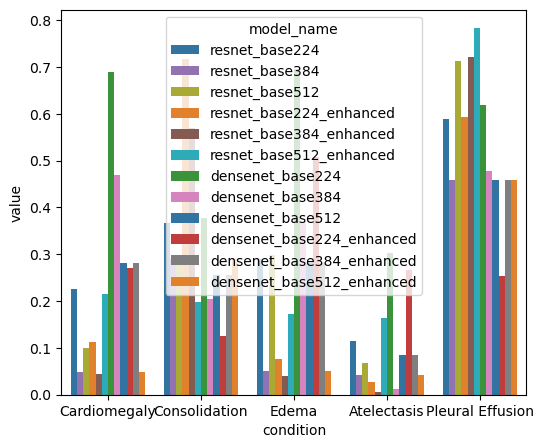

In [12]:
### Plotting TPR across models, one subplot per condition
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="positive_vs_negative") & \
    (results_df.metric=="TPR")
)
plot_df = results_df.loc[df_filter, :]
###

fig,ax = plt.subplots(1,1, figsize=(6,5))

sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", hue_order=order, palette=byModel_palette, ax=ax)

plt.show()

In [13]:
results_df.loc[results_df.metric_category=="certain_vs_uncertain",:]

,results_df_name,model_name,metric_category,condition,metric,value
60,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,TPU,0.338257
61,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,FPU,0.332868
62,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,FNU,0.661743
63,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,TNU,0.512638
64,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,FPU_AP,0.044891
...,...,...,...,...,...,...
1375,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,TNU_AP,0.177369
1376,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,TNU_AN,0.368980
1377,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,Precision,0.866749
1378,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,Recall,0.615076


In [14]:
metric = "TPU"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df_tpu = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
plot_df_tpu

,results_df_name,model_name,metric_category,condition,metric,value
334,test_results,densenet_base224,certain_vs_uncertain,Pleural Effusion,TPU,0.140337
323,test_results,densenet_base224,certain_vs_uncertain,Atelectasis,TPU,0.398455
301,test_results,densenet_base224,certain_vs_uncertain,Consolidation,TPU,0.242605
290,test_results,densenet_base224,certain_vs_uncertain,Cardiomegaly,TPU,0.243722
312,test_results,densenet_base224,certain_vs_uncertain,Edema,TPU,0.395724
449,test_results,densenet_base224_enhanced,certain_vs_uncertain,Pleural Effusion,TPU,0.200481
438,test_results,densenet_base224_enhanced,certain_vs_uncertain,Atelectasis,TPU,0.623570
427,test_results,densenet_base224_enhanced,certain_vs_uncertain,Edema,TPU,0.551029
416,test_results,densenet_base224_enhanced,certain_vs_uncertain,Consolidation,TPU,0.289116
405,test_results,densenet_base224_enhanced,certain_vs_uncertain,Cardiomegaly,TPU,0.654357


In [15]:
metric = "TNU"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df_tnu = results_df.loc[df_filter, :]

plot_df_tnu

,results_df_name,model_name,metric_category,condition,metric,value
63,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,TNU,0.512638
74,test_results,resnet_base224,certain_vs_uncertain,Consolidation,TNU,0.513560
85,test_results,resnet_base224,certain_vs_uncertain,Edema,TNU,0.318985
96,test_results,resnet_base224,certain_vs_uncertain,Atelectasis,TNU,0.504648
107,test_results,resnet_base224,certain_vs_uncertain,Pleural Effusion,TNU,0.600042
178,test_results,resnet_base224_enhanced,certain_vs_uncertain,Cardiomegaly,TNU,0.489714
189,test_results,resnet_base224_enhanced,certain_vs_uncertain,Consolidation,TNU,0.144635
200,test_results,resnet_base224_enhanced,certain_vs_uncertain,Edema,TNU,0.188659
211,test_results,resnet_base224_enhanced,certain_vs_uncertain,Atelectasis,TNU,0.587047
222,test_results,resnet_base224_enhanced,certain_vs_uncertain,Pleural Effusion,TNU,0.565707


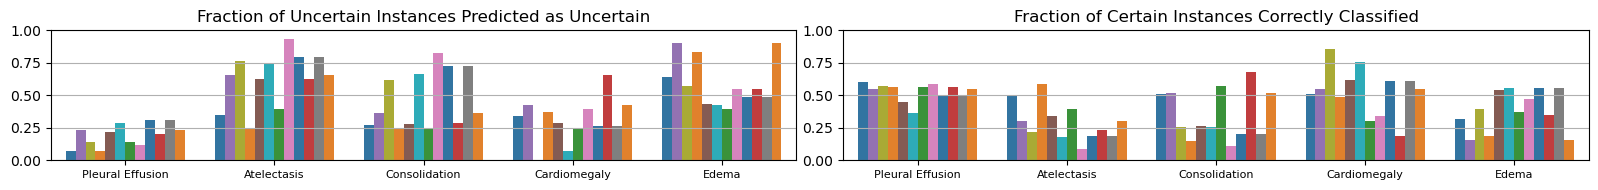

In [16]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(16,2))
###

metric = "TPU"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", order=plot_df["condition"], hue_order=order, palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_title("Fraction of Uncertain Instances Predicted as Uncertain")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].set_ylim(0,1)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "TNU"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", order=plot_df["condition"], hue_order=order, palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_title("Fraction of Certain Instances Correctly Classified")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].set_ylim(0,1)
ax[1].grid(axis="y")
ax[1].get_legend().remove()

plt.tight_layout()
plt.show()

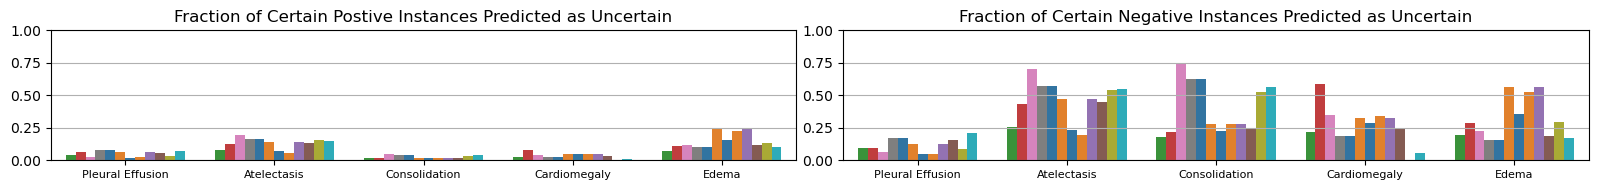

In [17]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(16,2))
###

metric = "FPU_AP"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_title("Fraction of Certain Postive Instances Predicted as Uncertain")
ax[0].set_ylim(0,1)
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "FPU_AN"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_title("Fraction of Certain Negative Instances Predicted as Uncertain")
ax[1].set_ylim(0,1)
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].grid(axis="y")
ax[1].get_legend().remove()

plt.tight_layout()
plt.show()

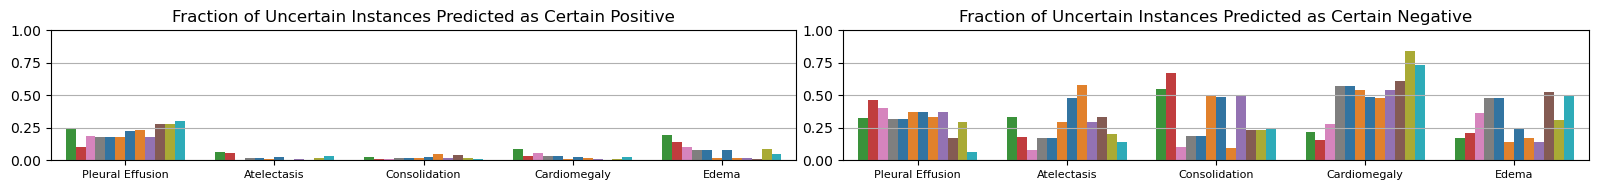

In [18]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(16,2))
###

metric = "TNU_AP"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
legend_ax = sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_title("Fraction of Uncertain Instances Predicted as Certain Positive")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].set_ylim(0,1)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "TNU_AN"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_title("Fraction of Uncertain Instances Predicted as Certain Negative")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].set_ylim(0,1)
ax[1].grid(axis="y")
ax[1].get_legend().remove()

plt.tight_layout()
plt.show()

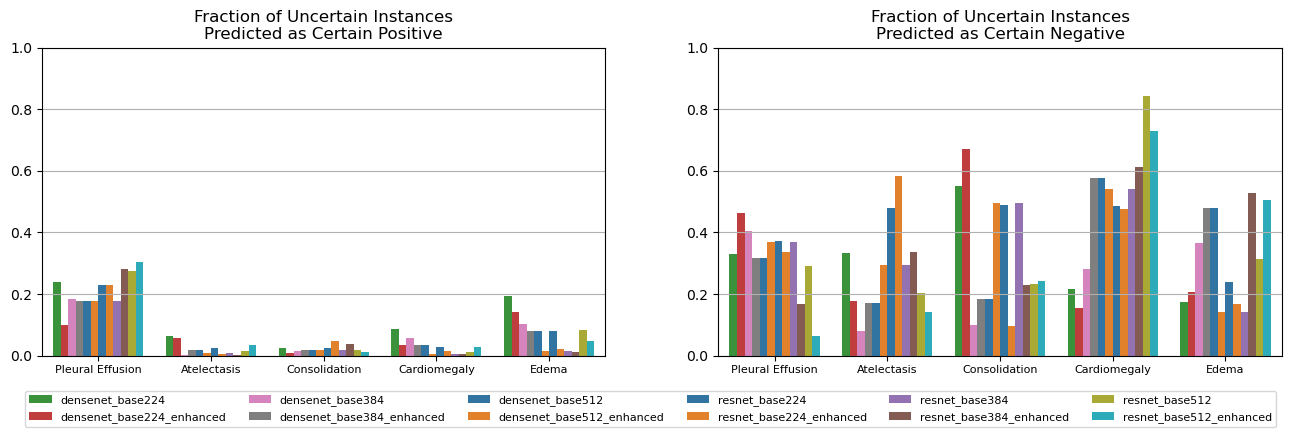

In [19]:
### Plotting TPR across models, one subplot per condition (WITH LEGEND)
fig,ax = plt.subplots(1,2, figsize=(16,4))
###

metric = "TNU_AP"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
legend_ax = sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_title("Fraction of Uncertain Instances\nPredicted as Certain Positive")
ax[0].set_ylim(0,1)
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].grid(axis="y")
ax[0].legend(ncol=6, loc="lower right", bbox_to_anchor=(2.2,-.25), fontsize=8)

metric = "TNU_AN"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_title("Fraction of Uncertain Instances\nPredicted as Certain Negative")
ax[1].set_ylim(0,1)
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].grid(axis="y")
ax[1].get_legend().remove()

# plt.tight_layout()
plt.show()

In [20]:
metric = "Precision"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]

plot_df.pivot_table(index="model_name", columns="condition", values="value")

condition,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
model_name,,,,,
densenet_base224,0.806844,0.839803,0.863496,0.843078,0.896131
densenet_base224_enhanced,0.743510,0.714282,0.848006,0.795619,0.880897
densenet_base384,0.682750,0.782282,0.699408,0.819115,0.922932
densenet_base384_enhanced,0.709457,0.856266,0.721240,0.850989,0.839289
densenet_base512,0.709457,0.856266,0.721240,0.850989,0.839289
densenet_base512_enhanced,0.731123,0.792742,0.818845,0.702800,0.866749
resnet_base224,0.815471,0.800812,0.841825,0.761561,0.939182
resnet_base224_enhanced,0.833638,0.781183,0.810180,0.709722,0.936229
resnet_base384,0.731123,0.792742,0.818845,0.702800,0.866749


In [21]:
metric = "Recall"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]

plot_df.pivot_table(index="model_name", columns="condition", values="value")

condition,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
model_name,,,,,
densenet_base224,0.699228,0.621861,0.621302,0.697862,0.570168
densenet_base224_enhanced,0.811785,0.827179,0.644558,0.775514,0.600241
densenet_base384,0.964745,0.697932,0.914047,0.775514,0.556937
densenet_base384_enhanced,0.897955,0.631462,0.864000,0.745058,0.654370
densenet_base512,0.897955,0.631462,0.864000,0.745058,0.654370
densenet_base512_enhanced,0.829591,0.711226,0.681488,0.950585,0.615076
resnet_base224,0.674843,0.669129,0.636930,0.820694,0.534884
resnet_base224_enhanced,0.625000,0.687592,0.620651,0.916499,0.534884
resnet_base384,0.829591,0.711226,0.681488,0.950585,0.615076


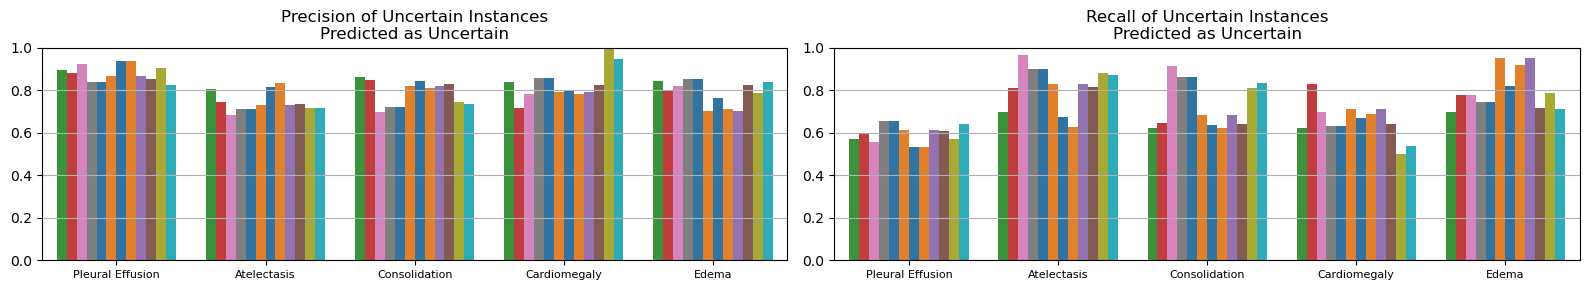

In [22]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(16,3))
###

metric = "Precision"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_title("Precision of Uncertain Instances\nPredicted as Uncertain")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].set_ylim(0,1)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "Recall"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_title("Recall of Uncertain Instances\nPredicted as Uncertain")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].set_ylim(0,1)
ax[1].grid(axis="y")
ax[1].get_legend().remove()

plt.tight_layout()
plt.savefig("results/model_metrics/Uncertain_Prec_Recall.png")
plt.show()

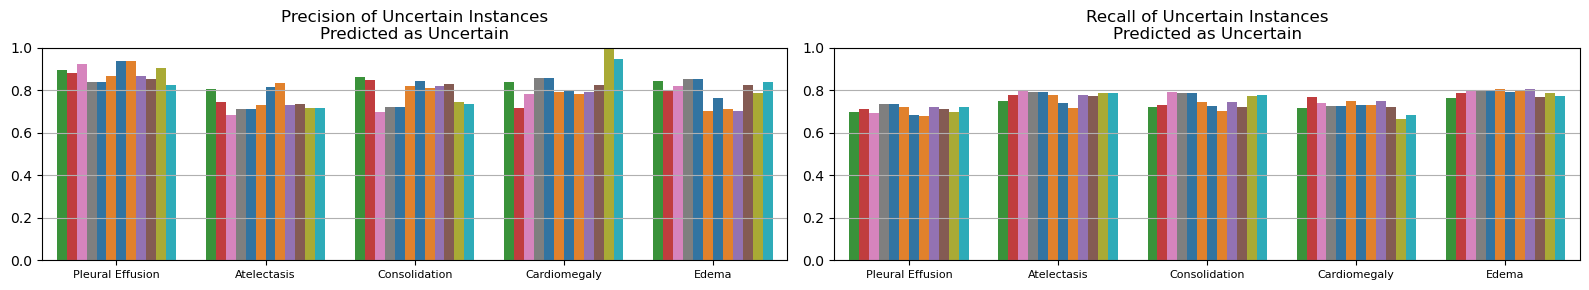

In [23]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(16,3))
###

metric = "Precision"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_title("Precision of Uncertain Instances\nPredicted as Uncertain")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].set_ylim(0,1)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "F1 Score"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :].sort_values(by="model_name", key=lambda x: x.map(model_map))
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_title("Recall of Uncertain Instances\nPredicted as Uncertain")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].set_ylim(0,1)
ax[1].grid(axis="y")
ax[1].get_legend().remove()

plt.tight_layout()
plt.savefig("results/model_metrics/Uncertain_Prec_Recall.png")
plt.show()